In [ ]:
#Download mediapipe to use in our model
!pip install mediapipe
!pip install --upgrade numpy mediapipe

  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)


### **Please re-run all cells after a runtime refresh as mediapipe install requires a kernel refresh.**

In [ ]:
#Import all required dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import mediapipe as mp

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
#Define the class names, we will test 10 classes
class_names = ['adho mukha svanasana', 'agnistambhasana', 'anantasana', 'ardha chandrasana',
               'dandasana', 'dhanurasana', 'hanumanasana', 'natrajasana', 'supta virasana', 'vajrasana']

In [ ]:
#Set up mediapipe pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose_detector = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

In [ ]:
#Set up transforms, using 224x224 to help get maximum data in each cell while avoiding overfitting, had previously tried with 150x150
transforms_common = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [ ]:
#Use data augmentation for training, previously trained without, some images are flipped and off-axis so we do this to incorporate randomness
transforms_augmented = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [ ]:
#Define a neural network model, using 4 convulation layers and finally flatten the images
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        # Input: 3x224x224
        self.conv1 = nn.Conv2d(3, 16, 5)  # Output: 16x220x220
        self.pool = nn.MaxPool2d(2, 2)    # Output: 16x110x110
        self.conv2 = nn.Conv2d(16, 32, 5) # Output: 32x106x106
        # After pooling: 32x53x53
        self.conv3 = nn.Conv2d(32, 64, 5) # Output: 64x49x49
        # After pooling: 64x24x24
        self.conv4 = nn.Conv2d(64, 128, 5) # Output: 128x20x20
        # After pooling: 128x10x10
        self.fc1 = nn.Linear(128 * 10 * 10, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
#Extract pose landmarks from images
def extract_pose_features(image_path):
    #Read image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not read image: {image_path}")
        return np.zeros(33 * 3)  # Return zeros if image can't be read

    #Convert colors to RGB for mediapipe use
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #Process the image to find pose landmarks
    results = pose_detector.process(image_rgb)

    #Initialize features array
    features = np.zeros(33 * 3)  # 33 landmarks with x, y, z coordinates
    #result is a 99-dimensional vector (33 landmarks × 3 coordinates)

    #If landmarks are detected, extract them
    if results.pose_landmarks:
        #idx defines the number of the pose we are working on
        for idx, landmark in enumerate(results.pose_landmarks.landmark):
            #Store x, y, z coordinates for each one
            features[idx*3] = landmark.x
            features[idx*3+1] = landmark.y
            features[idx*3+2] = landmark.z

    return features

In [ ]:
#We use both the normal CNN image model and combine it with mediapipe's landmark poses to obtain a better model
class CombinedModel(nn.Module):
    def __init__(self, pose_feature_size=33*3):
        super(CombinedModel, self).__init__()

        #CNN for image features
        self.cnn = NeuralNet()

        #Layers for pose features
        self.pose_fc1 = nn.Linear(pose_feature_size, 128)
        self.pose_fc2 = nn.Linear(128, 64)

        # Combined layers
        self.combined_fc1 = nn.Linear(84 + 64, 50)  # 84 from CNN and 64 from pose
        self.combined_fc2 = nn.Linear(50, 10)  # 10 output classes

        self.dropout = nn.Dropout(0.3)

    def forward(self, img, pose_features):
        # Process image through CNN
        x_img = self.cnn.pool(F.relu(self.cnn.conv1(img)))
        x_img = self.cnn.pool(F.relu(self.cnn.conv2(x_img)))
        x_img = self.cnn.pool(F.relu(self.cnn.conv3(x_img)))
        x_img = self.cnn.pool(F.relu(self.cnn.conv4(x_img)))
        x_img = torch.flatten(x_img, 1)
        x_img = F.relu(self.cnn.fc1(x_img))
        x_img = self.dropout(x_img)
        x_img = F.relu(self.cnn.fc2(x_img))

        # Process pose features
        x_pose = F.relu(self.pose_fc1(pose_features))
        x_pose = F.relu(self.pose_fc2(x_pose))

        # Combine features
        combined = torch.cat((x_img, x_pose), dim=1)
        x = F.relu(self.combined_fc1(combined))
        x = self.combined_fc2(x)

        return x

In [ ]:
#Custom dataset to handle both image and pose data
class YogaPoseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, extract_pose=True):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.extract_pose = extract_pose

        #Pre-extract pose features to speed up training and avoid doing it again and again
        if extract_pose:
            print("Extracting pose features from all images...")
            self.pose_features = []
            for i, img_path in enumerate(image_paths):
                if i % 50 == 0:
                    print(f"Processing image {i}/{len(image_paths)}")
                pose_feat = extract_pose_features(img_path)
                self.pose_features.append(pose_feat)
            self.pose_features = np.array(self.pose_features)
            print("Pose feature extraction complete!")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        #Load and transform image using the previous defined transformation
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        #Get the label and pose features
        label = self.labels[idx]

        if self.extract_pose:
            pose_feat = torch.tensor(self.pose_features[idx], dtype=torch.float32)
        else:
            #Extract pose features now if not pre-extracted
            pose_feat = torch.tensor(extract_pose_features(img_path), dtype=torch.float32)

        return image, pose_feat, label

In [ ]:
#Function to prepare the dataset for training
def prepare_dataset(data_dir):
    """Prepare dataset from directory structure."""
    all_image_paths = []
    all_labels = []

    #Get class folders
    class_folders = sorted([d for d in os.listdir(data_dir)
                           if os.path.isdir(os.path.join(data_dir, d))])

    print(f"Found {len(class_folders)} classes: {class_folders}")

    #Process each class and give number of images found for all classes
    for class_idx, class_folder in enumerate(class_folders):

        #Expected format data_dir/class_name/image_files
        folder_path = os.path.join(data_dir, class_folder)
        image_files = [f for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Found {len(image_files)} images for class: {class_folder}")

        for img_file in image_files:
            img_path = os.path.join(folder_path, img_file)
            all_image_paths.append(img_path)
            all_labels.append(class_idx)

    return all_image_paths, all_labels

In [ ]:
#Define training function with lr and epochs etc.
def train_model(model, train_loader, val_loader, num_epochs=30):
    """Train the model and return training history."""

    #Setup the loss function
    loss_function = nn.CrossEntropyLoss()

    #Using Adam optim to train SGD didn't work well for the dataset
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    #Learning rate schedular to reduce lr if epoch to epoch plateau
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    #Get metrics from the training
    train_losses = []
    val_losses = []
    val_accuracies = []
    best_accuracy = 0.0

    for epoch in range(num_epochs):
        #Training phase
        model.train()
        running_loss = 0.0

        for images, pose_features, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images, pose_features)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        #Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, pose_features, labels in val_loader:
                outputs = model(images, pose_features)
                loss = loss_function(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_epoch_loss = val_loss / len(val_loader)
        val_losses.append(val_epoch_loss)

        accuracy = 100 * correct / total
        val_accuracies.append(accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {val_epoch_loss:.4f}, '
              f'Accuracy: {accuracy:.2f}%')

        #Save the best model where the best epoch is chosen
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), 'best_combined_model.pth')
            print(f"Saved better model with accuracy: {accuracy:.2f}%")


    #Plot training history to visualize it
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

In [ ]:
#Function to visualize pose landmarks on an image
def visualize_pose(image_path, title=None):
    """Visualize the pose landmarks on the given image."""
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #Detect pose from model
    results = pose_detector.process(image_rgb)

    #Draw landmarks if detected for image
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image_rgb,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=1)
        )

    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.savefig(f"pose_{os.path.basename(image_path)}")
    plt.show()

In [ ]:
#Function to make predictions on new images
def predict_yoga_pose(model, image_path):
    """Predict yoga pose for a given image."""
    #Load and transform image to suitable processing format
    image = Image.open(image_path).convert('RGB')
    image_tensor = transforms_common(image).unsqueeze(0)

    #Extract pose features
    pose_features = extract_pose_features(image_path)
    pose_tensor = torch.tensor(pose_features, dtype=torch.float32).unsqueeze(0)

    #Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor, pose_tensor)
        probabilities = F.softmax(outputs, dim=1)[0]

        #Get top 3 predictions with probabilities
        values, indices = torch.topk(probabilities, 3)

    #Visualize pose landmarks
    visualize_pose(image_path, f"Prediction: {class_names[indices[0]]}")

    #Print top predictions
    print(f"Predictions for {os.path.basename(image_path)}:")
    for i, (prob, idx) in enumerate(zip(values, indices)):
        print(f"{i+1}. {class_names[idx]}: {prob.item()*100:.2f}%")

    return indices[0].item(), probabilities[indices[0]].item()


In [ ]:
!git clone https://github.com/shubhpsd/yoga-pose-detection.git

fatal: destination path 'yoga-pose-detection' already exists and is not an empty directory.
fatal: destination path 'yoga-pose-detection' already exists and is not an empty directory.


Found 10 classes: ['adho mukha svanasana', 'agnistambhasana', 'anantasana', 'ardha chandrasana', 'dandasana', 'dhanurasana', 'hanumanasana', 'natarajasana', 'supta virasana', 'vajrasana']
Found 69 images for class: adho mukha svanasana
Found 33 images for class: agnistambhasana
Found 43 images for class: anantasana
Found 52 images for class: ardha chandrasana
Found 60 images for class: dandasana
Found 46 images for class: dhanurasana
Found 35 images for class: hanumanasana
Found 72 images for class: natarajasana
Found 60 images for class: supta virasana
Found 54 images for class: vajrasana
Training set: 419 images
Validation set: 105 images
Extracting pose features from all images...
Processing image 0/419
Processing image 50/419
Processing image 100/419
Processing image 150/419
Processing image 200/419
Processing image 250/419
Processing image 300/419
Processing image 350/419
Processing image 400/419
Pose feature extraction complete!
Extracting pose features from all images...
Process

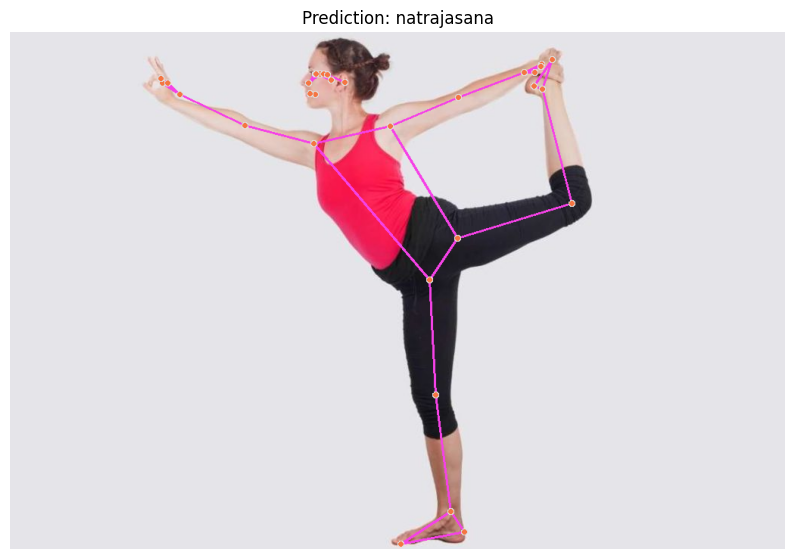

Predictions for example3.jpg:
1. natrajasana: 99.70%
2. ardha chandrasana: 0.21%
3. hanumanasana: 0.09%


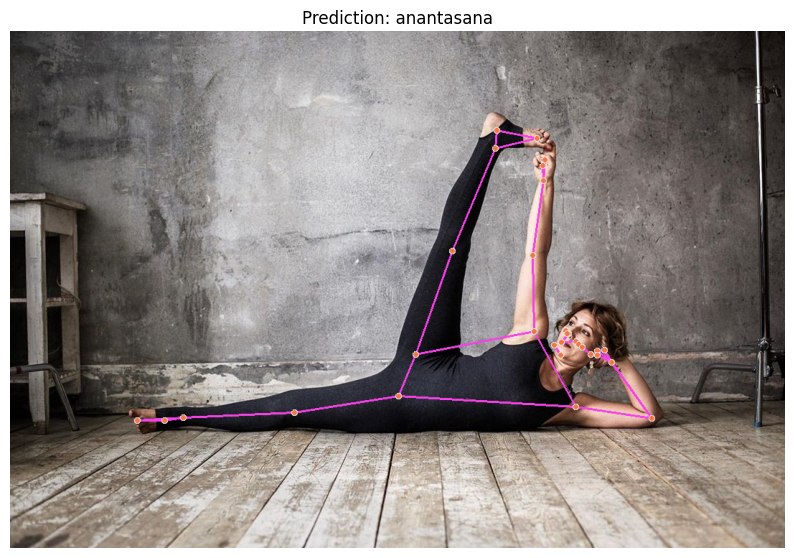

Predictions for example1.jpg:
1. anantasana: 94.07%
2. supta virasana: 2.45%
3. dhanurasana: 2.01%


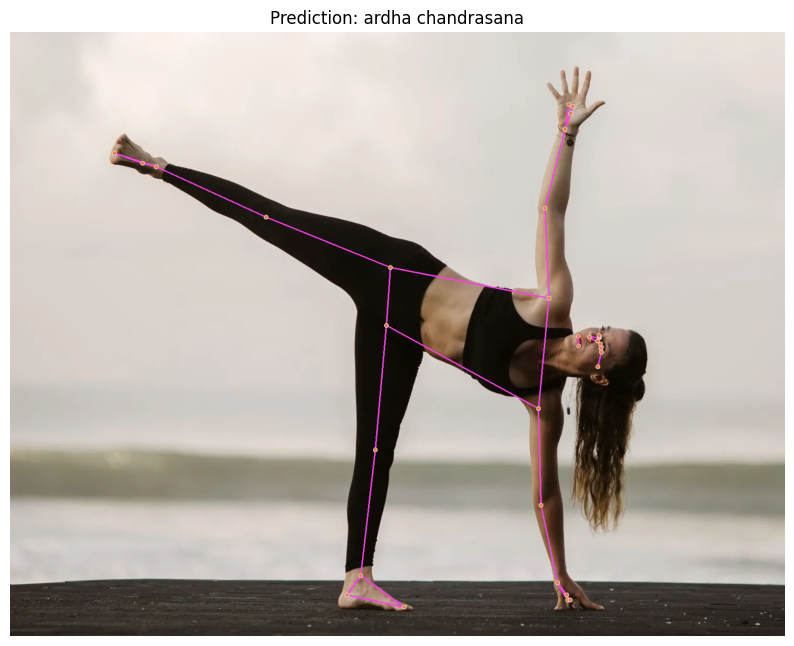

Predictions for example2.jpg:
1. ardha chandrasana: 99.74%
2. adho mukha svanasana: 0.24%
3. supta virasana: 0.01%
Found 10 classes: ['adho mukha svanasana', 'agnistambhasana', 'anantasana', 'ardha chandrasana', 'dandasana', 'dhanurasana', 'hanumanasana', 'natarajasana', 'supta virasana', 'vajrasana']
Found 69 images for class: adho mukha svanasana
Found 33 images for class: agnistambhasana
Found 43 images for class: anantasana
Found 52 images for class: ardha chandrasana
Found 60 images for class: dandasana
Found 46 images for class: dhanurasana
Found 35 images for class: hanumanasana
Found 72 images for class: natarajasana
Found 60 images for class: supta virasana
Found 54 images for class: vajrasana
Training set: 419 images
Validation set: 105 images
Extracting pose features from all images...
Processing image 0/419
Processing image 50/419
Processing image 100/419
Processing image 150/419
Processing image 200/419
Processing image 250/419
Processing image 300/419
Processing image 350

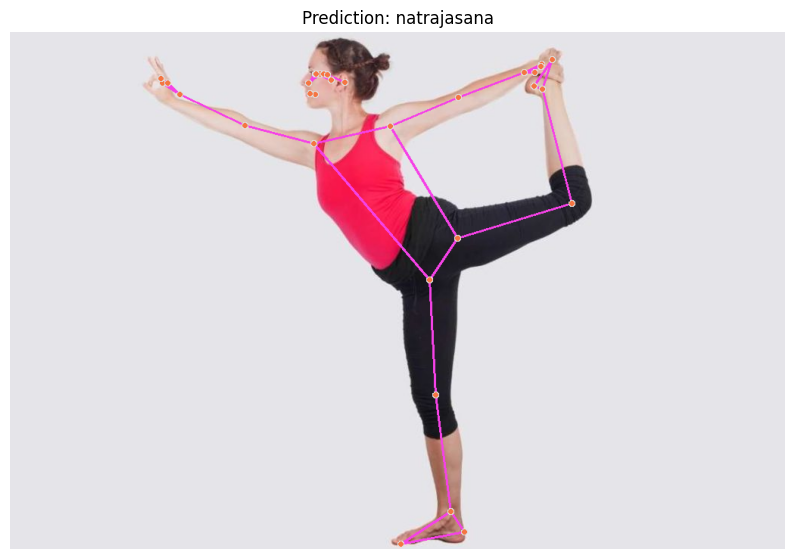

Predictions for example3.jpg:
1. natrajasana: 99.70%
2. ardha chandrasana: 0.21%
3. hanumanasana: 0.09%


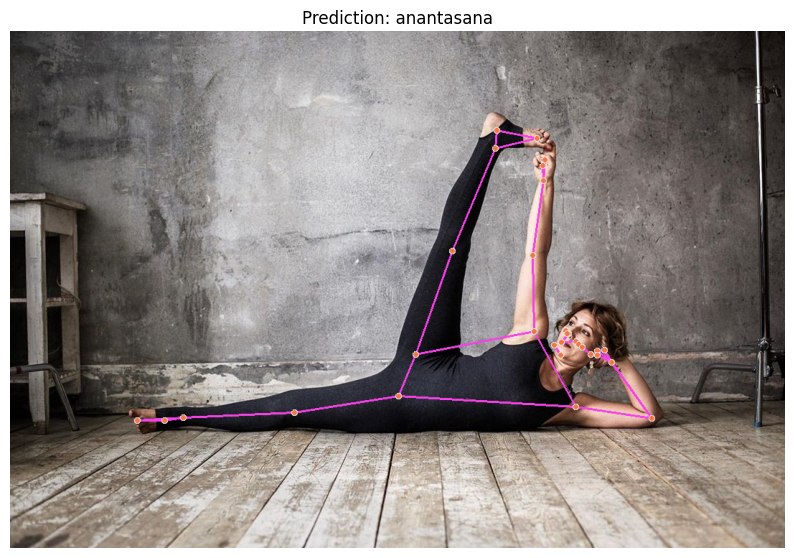

Predictions for example1.jpg:
1. anantasana: 94.07%
2. supta virasana: 2.45%
3. dhanurasana: 2.01%


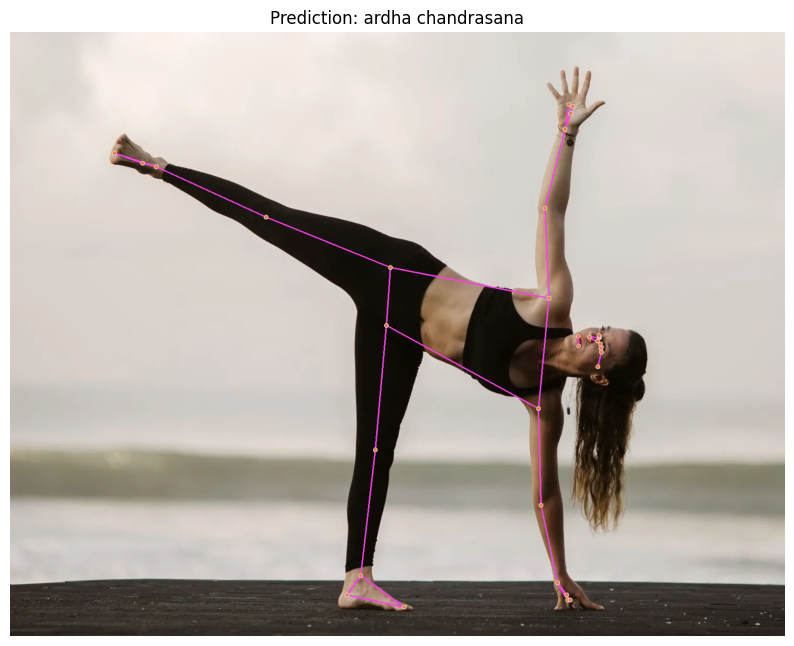

Predictions for example2.jpg:
1. ardha chandrasana: 99.74%
2. adho mukha svanasana: 0.24%
3. supta virasana: 0.01%


In [ ]:
#Main function to run both training and testing in one go
def run_yoga_pose_classifier(train_new=True, num_epochs=30, test_images=None):
    """Run the complete yoga pose classification pipeline."""
    #Data preparation and main data path
    data_dir = '/content/yoga-pose-detection/data/train/'
    image_paths, labels = prepare_dataset(data_dir)

    #Split data into 80%-20% ratio for each class
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        image_paths, labels, test_size=0.2, random_state=42, stratify=labels)

    print(f"Training set: {len(train_paths)} images")
    print(f"Validation set: {len(val_paths)} images")

    #Create datasets
    train_dataset = YogaPoseDataset(train_paths, train_labels, transform=transforms_augmented)
    val_dataset = YogaPoseDataset(val_paths, val_labels, transform=transforms_common)

    #Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    #Create model
    model = CombinedModel()

    #Train or load model if not existing
    if train_new and not os.path.exists('best_combined_model.pth'):
        print("Training new model...")
        train_model(model, train_loader, val_loader, num_epochs)
    else:
        if os.path.exists('best_combined_model.pth'):
            print("Loading existing model...")
            model.load_state_dict(torch.load('best_combined_model.pth'))
        else:
            print("No saved model found. Training new model...")
            train_model(model, train_loader, val_loader, num_epochs)

    # Test on example images or inputs
    if test_images is None:
        test_folder = '/content/yoga-pose-detection/test/'
        if os.path.exists(test_folder):
            # Get all image files in the test folder
            test_images = [
                os.path.join(test_folder, f)
                for f in os.listdir(test_folder)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
        else:
            print(f"Test folder not found: {test_folder}")
            test_images = []

    for img_path in test_images:
        if os.path.exists(img_path):
            predict_yoga_pose(model, img_path)
        else:
            print(f"Test image not found: {img_path}")

    return model

# Run the classifier if this script is executed directly
if __name__ == "__main__":
  run_yoga_pose_classifier(train_new=True, num_epochs=30)